<a href="https://colab.research.google.com/github/ranran1231314/my_new_portfolio/blob/main/Final_Project_Python_Pandas_(MatPlotLib)_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Analytics - Presentation - 18.6.2025

---



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
#dataset = pd.read_csv('HR-Employee-Attrition.csv')

file_path = '/content/drive/MyDrive/HR-Employee-Attrition.csv'
dataset = pd.read_csv(file_path)

# --------  General Information --------

---











In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
dataset

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,58,Yes,Travel_Rarely,147,Research & Development,23,4,Medical,1,165,...,4,80,1,40,3,2,40,10,15,6
1,58,No,Travel_Rarely,682,Sales,10,4,Medical,1,131,...,3,80,0,38,1,2,37,10,1,8
2,55,No,Travel_Rarely,685,Sales,26,5,Marketing,1,1578,...,3,80,1,36,3,3,36,6,2,13
3,55,No,Travel_Rarely,452,Research & Development,1,3,Medical,1,374,...,3,80,0,37,2,3,36,10,4,13
4,52,No,Travel_Rarely,621,Sales,3,4,Marketing,1,776,...,1,80,0,34,3,4,34,6,1,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,28,Yes,Travel_Frequently,289,Research & Development,2,2,Medical,1,1504,...,3,80,0,8,2,2,0,0,0,0
1466,19,Yes,Travel_Rarely,528,Sales,22,1,Marketing,1,167,...,4,80,0,0,2,2,0,0,0,0
1467,28,Yes,Travel_Rarely,529,Research & Development,2,4,Life Sciences,1,364,...,3,80,0,5,5,1,0,0,0,0
1468,18,No,Non-Travel,1431,Research & Development,14,3,Medical,1,1839,...,3,80,0,0,4,1,0,0,0,0


In [ ]:
#counting the people in each years count scale
dataset.YearsAtCompany.value_counts()

#counting the num of employees up to 10 years, gives us indication that most of the employees
#in the company are up to 10 years in the company (1224 people)

,count
YearsAtCompany,
5,196
1,171
3,128
2,127
10,120
4,110
7,90
9,82
8,80


In [ ]:
max_years = dataset['YearsAtCompany'].max()

In [ ]:
step = 10
max_years = dataset['YearsAtCompany'].max()

labels = ['0-3', '4-7', '8-11', '12-15', '16-19', '20-23', '24-27', '28-31', '32-35', '36-39','40+']

# Bins: from 1 to next 10-multiple above max value
num_labels = len(labels)
bins = list(range(1, int(np.ceil(max_years / step)) * step + 1, step))

if max_years >= bins[-1]:
    bins.append(max_years + 1)

if len(bins) > num_labels + 1:
    bins = bins[:num_labels + 1]

bins = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, dataset['YearsAtCompany'].max() + 1]

labels = ['0-3', '4-7', '8-11', '12-15', '16-19', '20-23', '24-27', '28-31', '32-35', '36-39','40+']

# Create binned column
dataset['TenureRange'] = pd.cut(dataset['YearsAtCompany'], bins=bins, labels=labels, right=False, include_lowest=True)


In [ ]:
print(dataset['TenureRange'].value_counts().sort_index())

TenureRange
0-3      470
4-7      472
8-11     314
12-15     76
16-19     45
20-23     58
24-27     16
28-31      6
32-35      9
36-39      3
40+        1
Name: count, dtype: int64


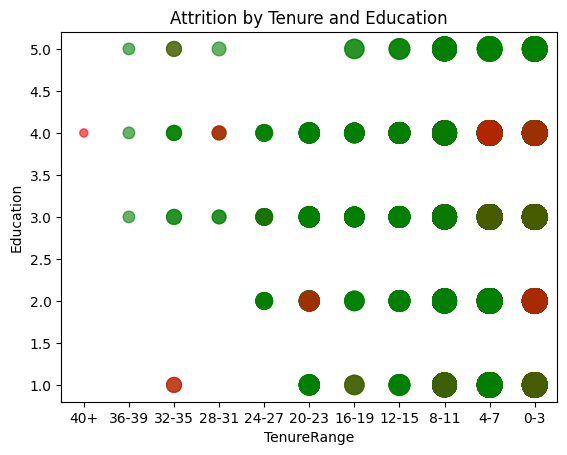

In [ ]:
dataset.plot(
    kind="scatter",
    x="TenureRange",
    y="Education",
    c=dataset['Attrition'].replace({"Yes": "red", "No": "green"}),
    # Apply logarithm to the counts before scaling for bubble size
    s=np.log(dataset['TenureRange'].map(dataset['TenureRange'].value_counts()).astype(float) + 1) * 50, # Added +1 to handle log(0),
    title='Attrition by Tenure and Education', alpha = 0.6
)

plt.show()

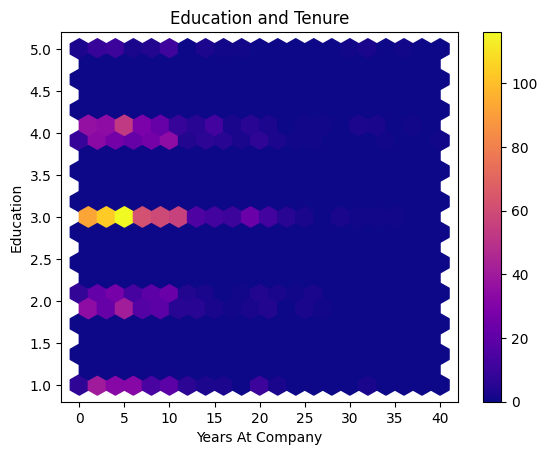

In [ ]:
#hexbin
#i need to check whether i can add attrition-yes or no - element here

n = 1470
ax = dataset.plot.hexbin(x='YearsAtCompany', y='Education', gridsize=20, xlabel = 'Years At Company', title = 'Education and Tenure', cmap="plasma")

In [ ]:
#scatter plot between 2 variables. we can use another dimension. to see with what i choose.
#according to the size. scatter. without group by. instead bar- to check relation in scatter plot.
#we can add color, and size- we can add.

there is better graph - hexbin

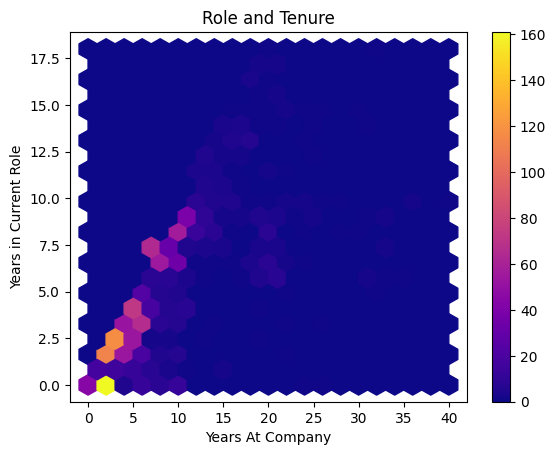

In [ ]:
n = 1470
ax = dataset.plot.hexbin(x='YearsAtCompany', y='YearsInCurrentRole', xlabel = 'Years At Company', ylabel = 'Years in Current Role', title = 'Role and Tenure', gridsize=20, cmap="plasma")

i need to check what it means. does it means that people who are more time in the company stays more in their current role? in this case the darker colors mean more time in the current role?

It looks like there are peaks of performance in any tenure, though the highest are above 23 years at the company.

hitmap

Correlations

In [ ]:
dataset.select_dtypes(include='number').corr()
#sns.heatmap("Education", vmin=30, vmax=70)
#plt.show()
#choose relevant columns

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


In [ ]:
correlation = dataset['JobSatisfaction'].corr(dataset['Education'])
print(correlation)

-0.011296116736573894


In [ ]:
correlation = dataset['JobSatisfaction'].corr(dataset['YearsAtCompany'])
print(correlation)

-0.003802627948287984


In [ ]:
dataset['Attrition'] = dataset['Attrition'].map({'Yes':True, 'No':False})

In [ ]:
dataset['Attrition'] = dataset['Attrition'].map({True: 1, False: 0})


In [ ]:
correlation = dataset['JobSatisfaction'].corr(dataset['Attrition'])
print(correlation)

-0.10348112606902117


In [ ]:
print(dataset['Attrition'])

0       1
1       0
2       0
3       0
4       0
       ..
1465    1
1466    1
1467    1
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64


there are better scale - connection between job satisfaction to education. maybe more educated will be less satisfied. with tenure years. same role- risk to leave.

<Axes: title={'center': 'Tenure and Education by Seniority'}, xlabel='Years At Company', ylabel='Job Level'>

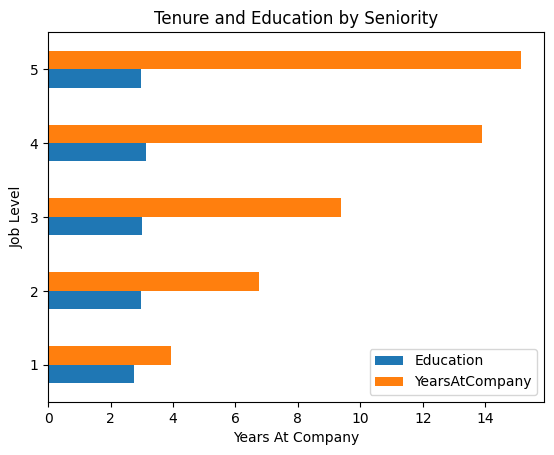

In [ ]:
dataset.groupby('JobLevel')[['Education','YearsAtCompany']].mean().plot(kind='barh', ylabel = 'Job Level', xlabel = 'Years At Company', title = 'Tenure and Education by Seniority')
#df2 = pd.DataFrame(np.random.rand(10, 4), columns=["Education", "TenureRange", "JobSatisfaction", "PerformanceRating"])
#df2.plot.barh()

<Axes: title={'center': 'Department Percentages'}, ylabel='Department'>

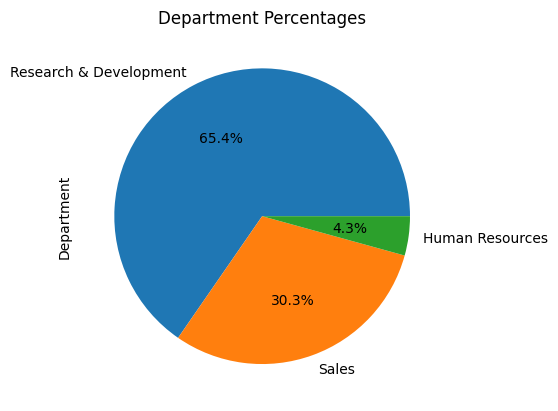

In [ ]:
dataset.Department.value_counts().plot(ylabel = 'Department', kind='pie', title = 'Department Percentages', autopct='%1.1f%%')

<Axes: title={'center': 'Attrition Percentages'}, ylabel='Worker Left?'>

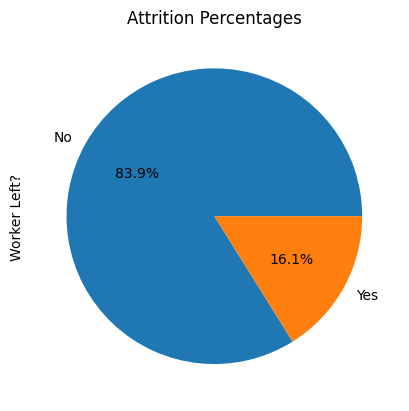

In [ ]:
dataset.Attrition.value_counts().plot(ylabel = 'Worker Left?', kind='pie', title = 'Attrition Percentages', autopct='%1.1f%%')

In [ ]:
# Group and prepare the data
dataset['Attrition'] = dataset['Attrition'].replace({'Yes': 'Left', 'No': 'Stayed'})

df = dataset.groupby(['Department', 'Attrition']).size().reset_index(name='Count')

# Create faceted pie charts (one pie per department)
fig = px.pie(
    df,
    values='Count',
    names='Attrition',
    facet_col='Department',  # Creates one pie per department
    color='Attrition',
    color_discrete_map={'Left': 'darkred', 'Stayed': 'lightgreen'},
    title='Attrition Percentages by Department (Left/Stayed)'
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(uniformtext_minsize=12, uniformtext_mode='hide')
fig.show()


the highest percentages per department of attrition is in sales.

<Axes: title={'center': 'Attrition by Job Satisfaction'}, xlabel='Attrition Rate', ylabel='Job Satisfaction'>

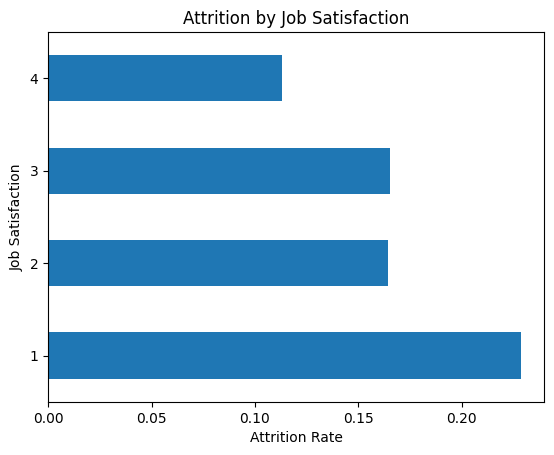

In [ ]:
dataset.groupby('JobSatisfaction')['Attrition'].mean().plot(kind='barh', xlabel = 'Attrition Rate', ylabel = 'Job Satisfaction', title = 'Attrition by Job Satisfaction')

it shows a bit higher attrition for lesser job satisfaction

# ----**Involvement Influence**-----

<Axes: title={'center': 'Attrition by Involvement Level'}, xlabel='Attrition Rate', ylabel='Job Involvement'>

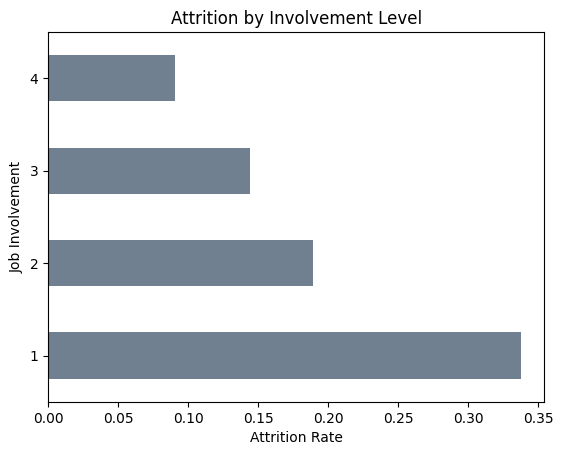

In [ ]:
dataset.groupby('JobInvolvement')['Attrition'].mean().plot(kind='barh', color='slategrey', xlabel = 'Attrition Rate', ylabel = 'Job Involvement', title = 'Attrition by Involvement Level')

it shows a bit higher attrition for lesser job involvement

<Axes: ylabel='WorkLifeBalance'>

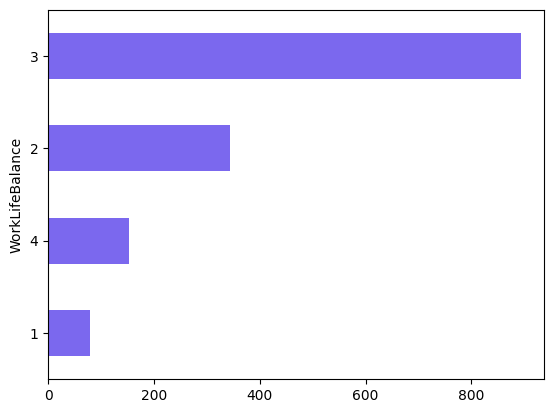

In [ ]:
dataset.WorkLifeBalance.value_counts().sort_values().plot(kind='barh', color= 'mediumslateblue')

The highest percentages reported wlb is 3. Almost 900 employees.

In [ ]:
dataset.WorkLifeBalance.mean()

np.float64(2.7612244897959184)

<Axes: ylabel='YearsSinceLastPromotion'>

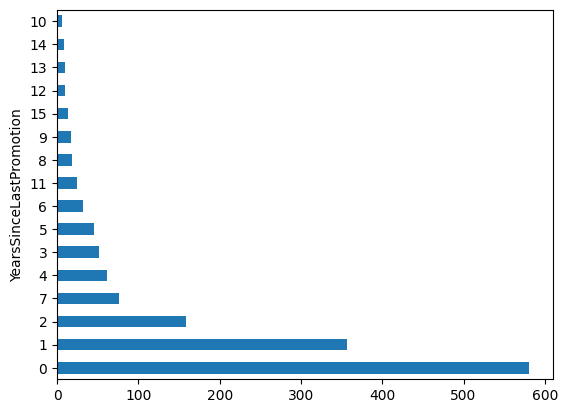

In [ ]:
dataset.YearsSinceLastPromotion.value_counts().plot.barh()

In [ ]:
dataset.YearsSinceLastPromotion.mean()

np.float64(2.1877551020408164)

In [ ]:
dataset.JobLevel.mean()

np.float64(2.0639455782312925)

<Axes: ylabel='JobLevel'>

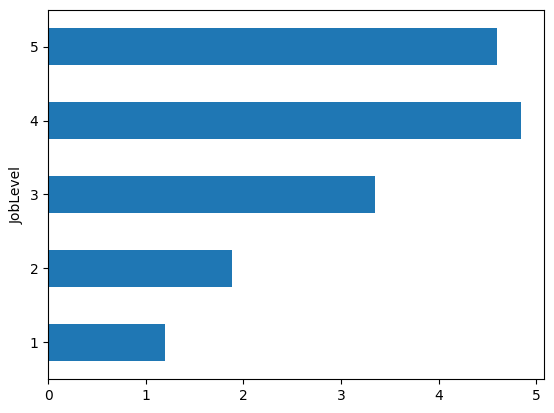

In [ ]:
dataset.groupby('JobLevel')['YearsSinceLastPromotion'].mean().plot(kind='barh')

as long as the job level is higher, the years since last promotion are higher.
because as long as the person is more senior at the company, he stayed a lot after the promotion of them, in their field.

In [ ]:
dataset.YearsWithCurrManager.mean()

np.float64(4.12312925170068)

the mean of years with current manager is 4.12

<Axes: title={'center': 'Involvement and Manager'}, xlabel='Years with same manager', ylabel='JobInvolvement'>

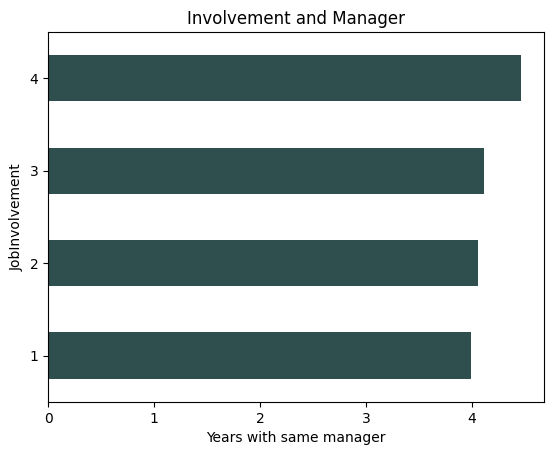

In [ ]:
dataset.groupby('JobInvolvement')['YearsWithCurrManager'].mean().plot(kind='barh', color ='darkslategray', xlabel = 'Years with same manager', title = 'Involvement and Manager')

people with higher jobinvolvement sticks more time with the same manager
not exactly true. slightly near the higest time with manager, higher job involvemnet

<Axes: title={'center': 'Attrition by Environment Satisfaction'}, xlabel='Attrition Rate', ylabel='Environment Satisfaction'>

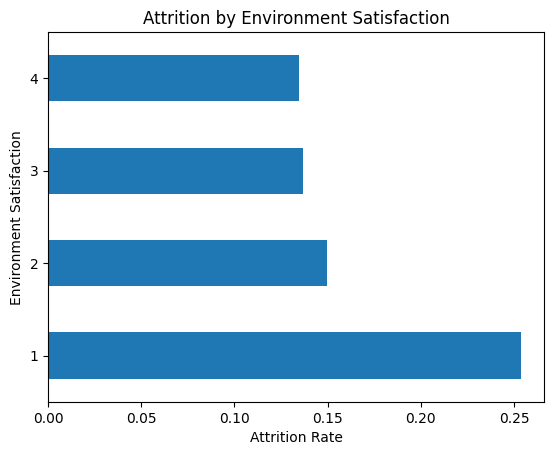

In [ ]:
dataset.groupby('EnvironmentSatisfaction')['Attrition'].mean().plot(kind='barh', title = 'Attrition by Environment Satisfaction', xlabel = 'Attrition Rate', ylabel = 'Environment Satisfaction')

It looks like the ones with lower environment satisfaction, are tend to leave more.....

In [ ]:
dataset.EnvironmentSatisfaction.value_counts()

,count
EnvironmentSatisfaction,
3,453
4,446
2,287
1,284


                                                   
#                                         ------  **Financial Compensations** -------

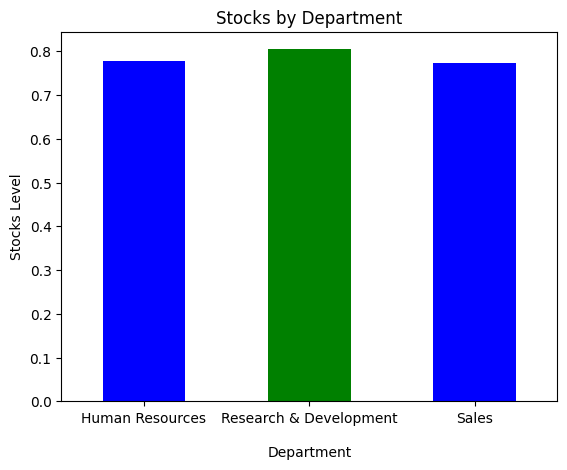

In [ ]:
dataset.groupby('Department')['StockOptionLevel'].mean().plot(
    kind='bar',
    title='Stocks by Department',
    ylabel='Stocks Level',
    color=['blue', 'green', 'blue']
)

plt.xticks(rotation=0)  # Set x-axis labels to horizontal
plt.xlabel('Department', labelpad=15)
plt.show()


By department, the research and development earnings the most stocks

<Axes: title={'center': 'Stocks Level by a Job Role'}, xlabel='Job Role', ylabel='Stocks Level'>

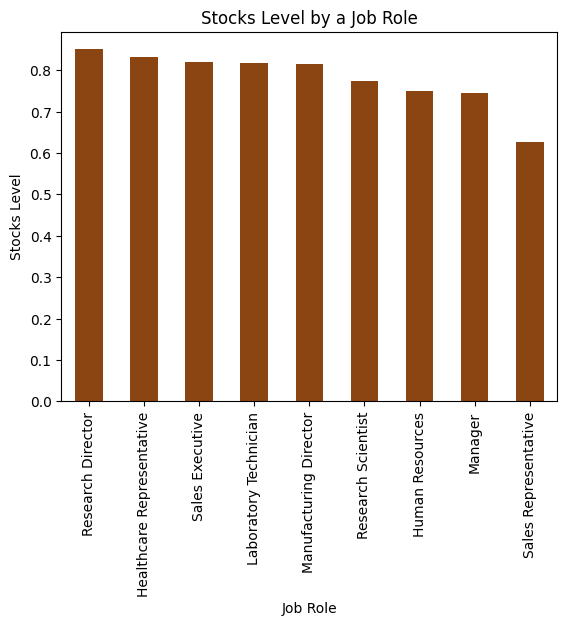

In [ ]:
#dataset.groupby[('JobRole')].sort_values(by=['StockOptionLevel'], ascending=False).plot(kind='bar')
dataset.groupby('JobRole')['StockOptionLevel'].mean().sort_values(ascending = False).plot(ylabel ='Stocks Level', xlabel ='Job Role', title = 'Stocks Level by a Job Role', kind='bar', color = 'saddlebrown')

it looks like the one with the highest stockoptionlevel is the research director

it looks like the ones who are most at the company are the most satisfied. there is a breakdown near the 35 years mark (like a marathon haha), another one near the 30 years mark, and beside of that quite status quo. ups and downs.

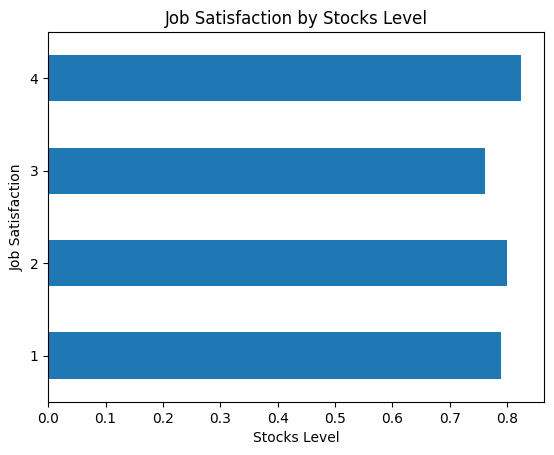

In [ ]:
dataset.groupby('JobSatisfaction')['StockOptionLevel'].mean().plot(xlabel ='Stocks Level', ylabel ='Job Satisfaction', title = 'Job Satisfaction by Stocks Level', kind='barh')

plt.show()

<Axes: title={'center': 'Attrition Rate by Stocks Level'}, xlabel='StockOptionLevel', ylabel='Attrition Rate'>

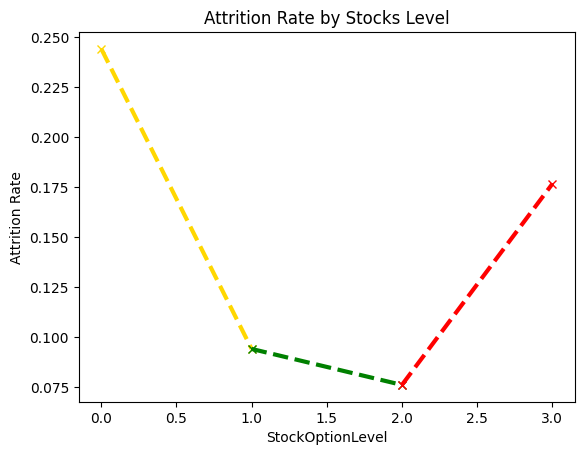

In [ ]:
dataset.groupby('StockOptionLevel')['Attrition'].mean().iloc[:2].plot.line(ylabel = 'Attrition Rate', title = 'Attrition Rate by Stocks Level', lw=3, c='gold', style="--", marker="x")
dataset.groupby('StockOptionLevel')['Attrition'].mean().iloc[1:3].plot.line(lw=3, c='green', style="--", marker="x")
dataset.groupby('StockOptionLevel')['Attrition'].mean().iloc[2:4].plot.line(lw=3, c='red', style="--", marker="x")

Facinated insight - the employees with lower stocks option tend to leave the company more. in a certain level they are tend to stay more at the copmany, but above certain amount of stocks they allow themselves to leave more the company. It can be due to some reasons: they have enough money and they can quit, they are getting high stocks level (for example r&d employees) also in other companies and they don't feel obliged to this company, their options are completley vested (and maybe it considered it arrived to the final level), therefore they don't have what to earn anymore.

the insight said that we should keep the stock options around 1 to 2. above certain amount it becomes dangerous

# Averages:

---



In [ ]:
#avg worklifebalance
display(dataset['WorkLifeBalance'].mean())
display(dataset.WorkLifeBalance.value_counts())

np.float64(2.7612244897959184)

,count
WorkLifeBalance,
3,893
2,344
4,153
1,80


In [ ]:
#avg jobsatisfaction
dataset['JobSatisfaction'].mean()

np.float64(2.7285714285714286)

In [ ]:
#avg YearsAtCompany
dataset['YearsAtCompany'].mean()

#it's a company with high retention, which is the opposite of attrition

np.float64(7.0081632653061225)

In [ ]:
#avg YearsInCurrentRole
dataset['YearsInCurrentRole'].mean()

#people are staying in the same role for over 4 years. how are they so engaged?

np.float64(4.229251700680272)

In [ ]:
#avg YearsWithCurrentManager
dataset['YearsWithCurrManager'].mean()

#around the same time in the same role. makes sense

np.float64(4.12312925170068)

In [ ]:
#avg YearsSinceLastPromotion
dataset['YearsSinceLastPromotion'].mean()

#the average years for promotion is after 2 years

np.float64(2.1877551020408164)

Business-Travel-and Marriage

<Axes: title={'center': 'Travel Rate by Marital Status'}, xlabel='Marital Status', ylabel='Num of Employees'>

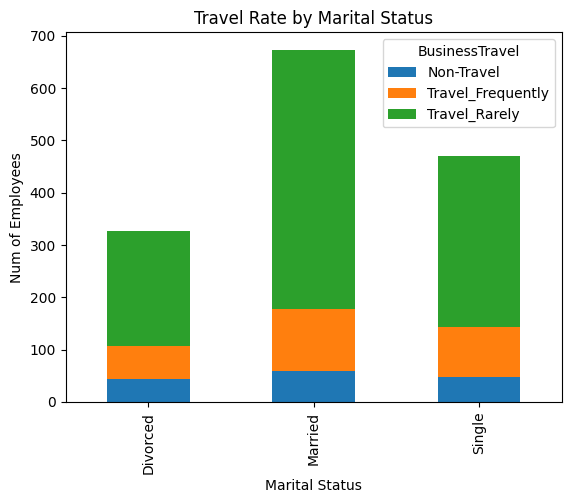

In [ ]:
dataset.groupby('MaritalStatus')['BusinessTravel'].value_counts().unstack().plot(kind='bar', stacked = True, ylabel = 'Num of Employees', xlabel = 'Marital Status', title = 'Travel Rate by Marital Status')

KeyError: 'Travel_Frequently'

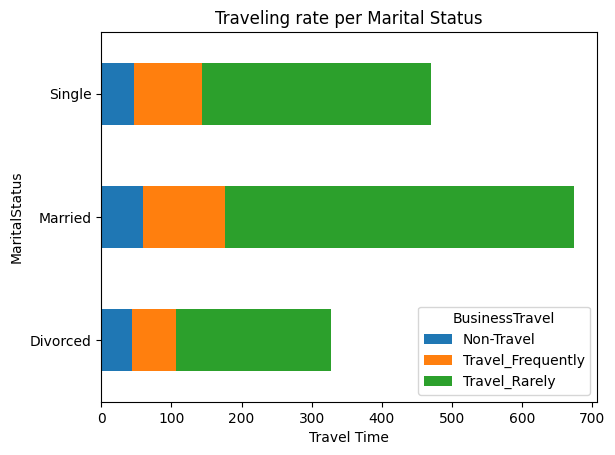

In [ ]:
#check whether being divorced leads to more frequent business travel

dataset.groupby('MaritalStatus')['BusinessTravel'].value_counts().unstack().plot(kind='barh',
xlabel = 'Travel Time',
stacked = True, title = 'Traveling rate per Marital Status', mark_right = True)

dataset_total = dataset["Travel_Frequently"] + dataset["Travel_Rarely"] + dataset["Non-Travel"]
dataset_rel = dataset[dataset.columns[1:]].div(dataset_total, 0)*100

for n in dataset_rel:
    for i, (cs, ab, pc) in enumerate((dataset.iloc[:, 1:].cumsum(1)[n],
                                         dataset[n], dataset_rel[n])):
        plt.text(cs - ab / 2, i, str(np.round(pc, 1)) + '%',
                 va = 'center', ha = 'center')       #.value_counts().unstack().plot(kind='bar',stacked = True, autopct='%1.1f%%')


In [ ]:
#Deciphering the results
#According to the results it shows that married people travel the most, then single, then divorced.
#Probably it is because there are the most married people.
#And maybe the divorced ones need to stay with their children and they don't have anyone to back them up. Interesting…..


i need to add the percentages of each travel status to each of the marital status. and then I can infer who are the ones who prone to travel more.